# Stage 1: Spherical Gradient Descent Training (Shared Embedding)

This notebook demonstrates Stage 1 training with **shared embedding** (`share_embed=True`), where input embeddings are summed: $e_x + e_y$.

This is appropriate for **commutative** operations like addition: $(x + y) \mod n$.

**Double phase phenomenon**: For quadratic activation, $2\phi_{in} \approx \psi_{out}$.

In [67]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src import Config, SphericalTrainer, get_task, get_basis

## 1. Configuration

In [68]:
# === Task Configuration ===
# Option 1: 1-d case (standard modular addition over Z_p)
#   Use p=17 for the group Z_17
#
# Option 2: d-dimensional case (component-wise addition over Z_{n_1} x ... x Z_{n_d})
#   Use n=[5, 7] for the group Z_5 x Z_7 (vocab_size = 35)
#   Use n=[3, 3, 3] for Z_3 x Z_3 x Z_3 (vocab_size = 27)

config = Config(
    # Task - choose one:
    task_name='modular_addition',
    #p=17,           # 1-d case: Z_17
    n=[3, 5],     # d-dim case: Z_5 x Z_7 (uncomment to use)
    
    # Model
    width=128,
    act_type='Quad',
    init_scale=0.5,
    share_embed=True,  # True for commutative (addition), False for non-commutative (subtraction)
    
    # Initialization type (only for modular tasks with Fourier basis):
    #   'iid': Both θ and ξ are IID on unit sphere (default)
    #   'matched_scale': θ is IID on sphere, ξ has same Fourier magnitudes as θ but random phases
    init_type='matched_scale',
    
    # Stage 1: Projected GD on sphere
    stage1_enabled=True,
    stage1_lr=1e-1,
    stage1_num_epochs=20000,
    stage1_optimizer='SGD',
    stage1_freeze_scales=True,
    
    # Stage 2: Disabled for now
    stage2_enabled=False,
    
    # Logging
    print_every=1000,
    track_phases=True,
    track_scales=True,
    snapshot_every=100,  # Save model snapshots every N epochs (0 = disabled)
    
    # System
    seed=42,
)

# Seeds are set automatically in Config.__post_init__()
print(f"Device: {config.device}")
print(f"Task: {config.task_name}")
print(f"Moduli: {config.moduli} (vocab_size={config.d_vocab})")
print(f"Model: width={config.width}, activation={config.act_type}, share_embed={config.share_embed}")
print(f"Initialization: {config.init_type}")
print(f"Snapshot every: {config.snapshot_every} epochs")

Device: auto
Task: modular_addition
Moduli: [3, 5] (vocab_size=15)
Model: width=128, activation=Quad, share_embed=True
Initialization: matched_scale
Snapshot every: 100 epochs


## 2. Initialize Trainer

In [69]:
trainer = SphericalTrainer(config)

print(f"\nModel architecture:")
print(f"  W_in:  {trainer.model.W_in.shape}")
print(f"  W_out: {trainer.model.W_out.shape}")
print(f"  scale_in:  {trainer.model.scale_in.item():.4f}")
print(f"  scale_out: {trainer.model.scale_out.item():.4f}")

print(f"\nBasis: {trainer.basis}")
print(f"Dataset: {len(trainer.data)} samples (|G|^2 = {config.d_vocab**2})")

Initialized SphericalTrainer:
  Task: ModularAddition(n=[3, 5], vocab_size=15)
  Basis: FourierBasis(n=[3, 5], size=15)
  Device: cpu
  Data size: 225
  Model:
WideNetworkScaleSphere(
  d_vocab=15,
  width=128,
  act_type='Quad',
  share_embed=True,
  d_input=15,
  scale_in=0.5000,
  scale_out=0.5000
)

Model architecture:
  W_in:  torch.Size([128, 15])
  W_out: torch.Size([15, 128])
  scale_in:  0.5000
  scale_out: 0.5000

Basis: FourierBasis(n=[3, 5], size=15)
Dataset: 225 samples (|G|^2 = 225)


## 3. Run Stage 1 Training

In [70]:
# Save initial weights before training
W_in_init = trainer.model.W_in.detach().cpu().clone()
W_out_init = trainer.model.W_out.detach().cpu().clone()

# Run training
stage1_history, stage2_history = trainer.train()


Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000
Learning rates: W_in=0.050000, W_out=0.100000
Epoch     0 | Loss: 609.317383 | Acc: 0.0400
Epoch  1000 | Loss: 609.129517 | Acc: 0.4000
Epoch  2000 | Loss: 608.997864 | Acc: 0.6356
Epoch  3000 | Loss: 608.913086 | Acc: 0.8400
Epoch  4000 | Loss: 608.849915 | Acc: 0.9378
Epoch  5000 | Loss: 608.797363 | Acc: 0.9644
Epoch  6000 | Loss: 608.753662 | Acc: 0.9822
Epoch  7000 | Loss: 608.718689 | Acc: 0.9911
Epoch  8000 | Loss: 608.692139 | Acc: 1.0000
Epoch  9000 | Loss: 608.672791 | Acc: 1.0000
Epoch 10000 | Loss: 608.658997 | Acc: 1.0000
Epoch 11000 | Loss: 608.649231 | Acc: 1.0000
Epoch 12000 | Loss: 608.642334 | Acc: 1.0000
Epoch 13000 | Loss: 608.637695 | Acc: 1.0000
Epoch 14000 | Loss: 608.634399 | Acc: 1.0000
Epoch 15000 | Loss: 608.632141 | Acc: 1.0000
Epoch 16000 | Loss: 608.630615 | Acc: 1.0000
Epoch 17000 | Loss: 608.629578 | Acc: 1.0000
Epoch 18000 | Loss: 608.628845 | Acc: 1.0000
E

## 4. Single Frequency Phenomenon

Each neuron tends to specialize to a single dominant frequency in Fourier space.

In [71]:
# Compute Fourier transform of weights (init and trained)
basis = trainer.basis

# Trained weights
W_in = trainer.model.W_in.detach().cpu()
W_out = trainer.model.W_out.detach().cpu()

# Normalize to unit vectors
W_in_norm = W_in / W_in.norm(dim=1, keepdim=True)
W_out_norm = W_out / W_out.norm(dim=0, keepdim=True)
W_in_init_norm = W_in_init / W_in_init.norm(dim=1, keepdim=True)
W_out_init_norm = W_out_init / W_out_init.norm(dim=0, keepdim=True)

# Apply complex Fourier transform
W_in_dft = basis.transform(W_in_norm)        # Trained
W_out_dft = basis.transform(W_out_norm.T)
W_in_init_dft = basis.transform(W_in_init_norm)   # Initial
W_out_init_dft = basis.transform(W_out_init_norm.T)

# Get magnitudes
W_in_mag = torch.abs(W_in_dft).numpy()
W_out_mag = torch.abs(W_out_dft).numpy()
W_in_init_mag = torch.abs(W_in_init_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f"W_in_dft shape: {W_in_dft.shape}")
print(f"W_out_dft shape: {W_out_dft.shape}")

W_in_dft shape: torch.Size([128, 15])
W_out_dft shape: torch.Size([128, 15])


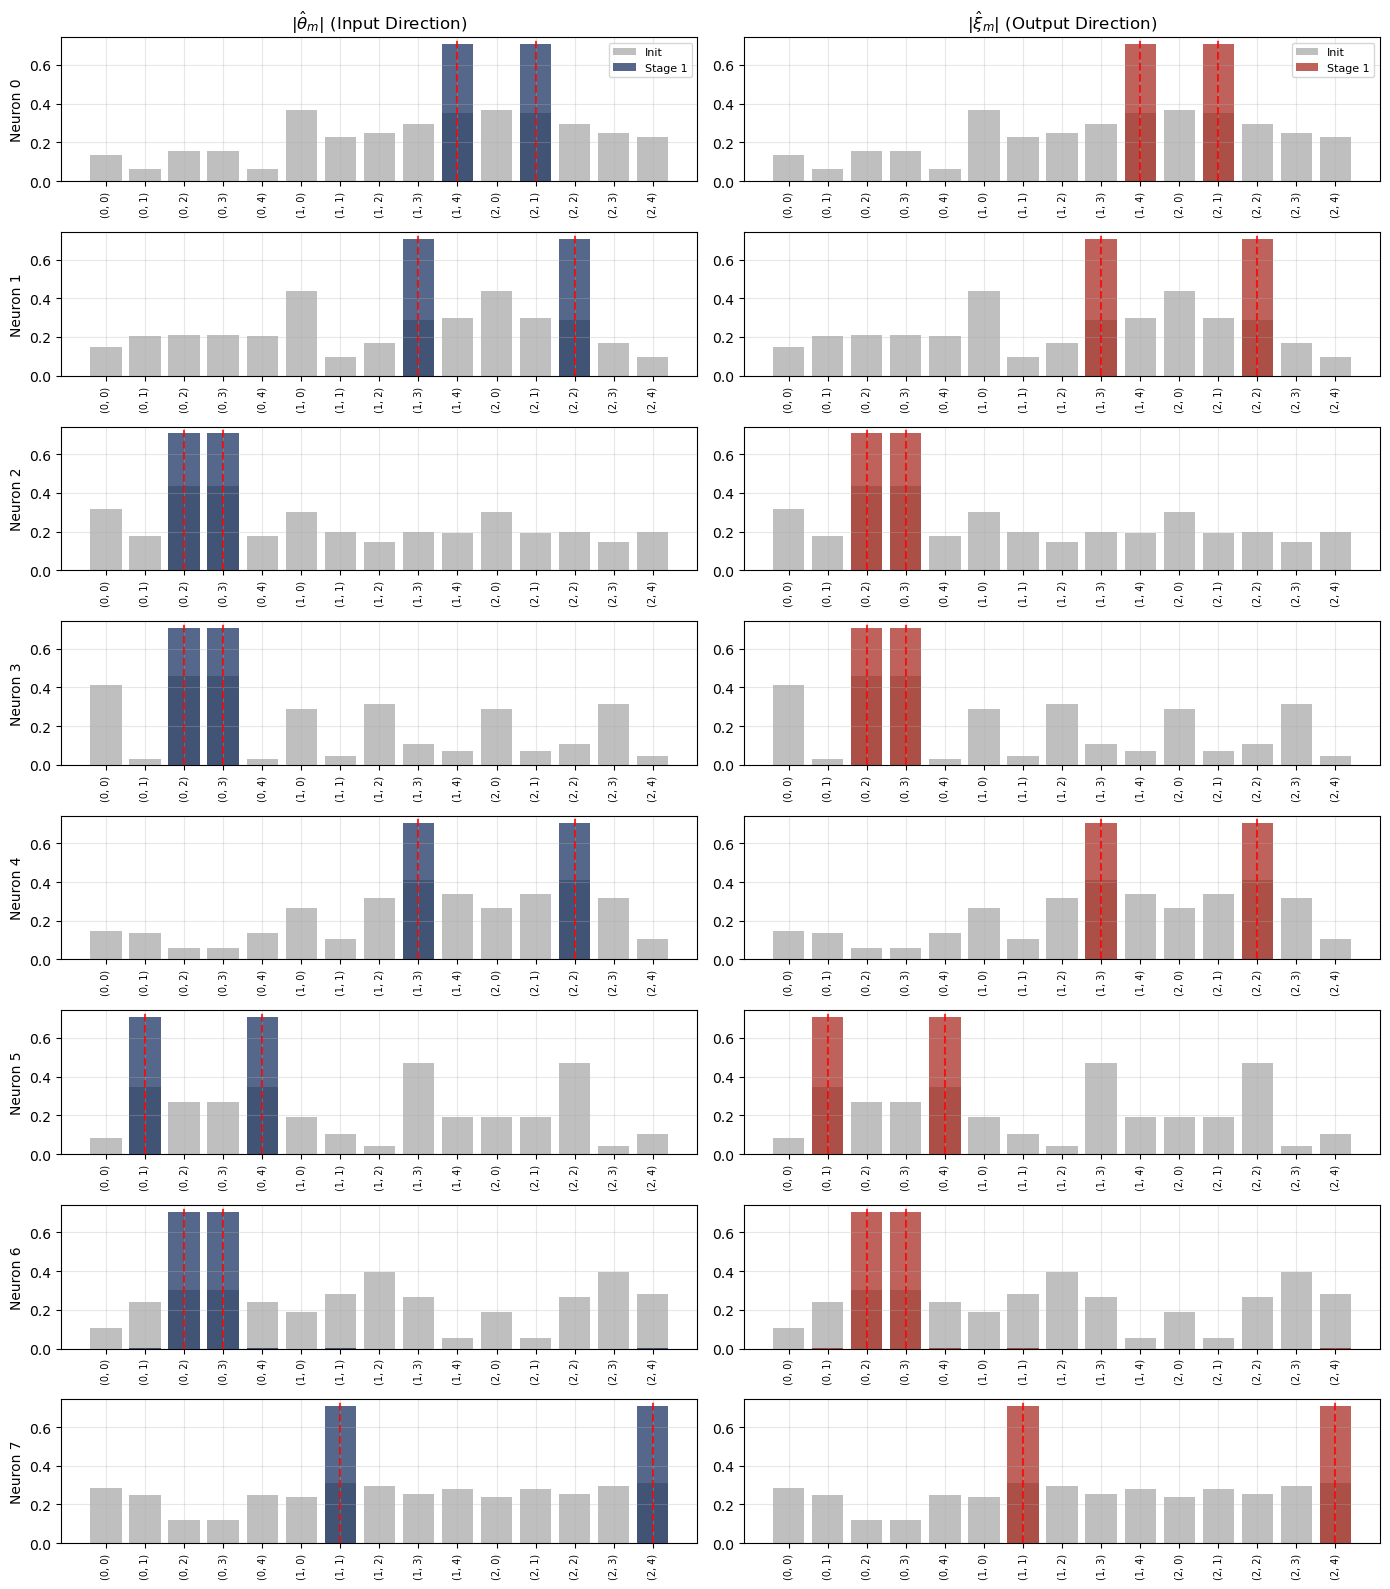

In [72]:
# Plot DFT comparison: Init (gray) vs Stage 1 (color)
# Note: For real signals, |ŝ[k]| = |ŝ[-k]| (conjugate symmetry)
num_neurons = 8
freq_indices = np.arange(config.d_vocab)

# Get frequency tuples for x-axis labels
freq_labels = [str(basis.get_frequency_tuple(k)) for k in range(config.d_vocab)]

def get_conjugate_freq(k_idx, moduli):
    """Get the conjugate frequency index: -k mod n."""
    k_tuple = basis.get_frequency_tuple(k_idx)
    conj_tuple = tuple((-k_j) % n_j for k_j, n_j in zip(k_tuple, moduli))
    return basis.tuple_to_index(conj_tuple)

fig, axes = plt.subplots(num_neurons, 2, figsize=(14, 2 * num_neurons))

for m in range(num_neurons):
    # W_in (θ_m) - Input Direction
    ax = axes[m, 0]
    ax.bar(freq_indices, W_in_init_mag[m], alpha=0.5, color='gray', label='Init')
    ax.bar(freq_indices, W_in_mag[m], alpha=0.7, color='#0D2758', label='Stage 1')
    
    # Mark dominant frequencies
    dom_freq_in = basis.get_dominant_frequency(W_in_dft[m])
    dom_tuple_in = basis.get_frequency_tuple(dom_freq_in)
    conj_freq_in = get_conjugate_freq(dom_freq_in, config.moduli)
    conj_tuple_in = basis.get_frequency_tuple(conj_freq_in)
    ax.axvline(x=dom_freq_in, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    if conj_freq_in != dom_freq_in and conj_freq_in != 0:
        ax.axvline(x=conj_freq_in, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    ax.set_ylabel(f'Neuron {m}')
    ax.set_xticks(freq_indices)
    ax.set_xticklabels(freq_labels, rotation=90, ha='center', fontsize=7)
    if m == 0:
        ax.set_title('$|\\hat{\\theta}_m|$ (Input Direction)')
        ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # W_out (ξ_m) - Output Direction
    ax = axes[m, 1]
    ax.bar(freq_indices, W_out_init_mag[m], alpha=0.5, color='gray', label='Init')
    ax.bar(freq_indices, W_out_mag[m], alpha=0.7, color='#A32015', label='Stage 1')
    
    # Mark dominant frequencies
    dom_freq_out = basis.get_dominant_frequency(W_out_dft[m])
    dom_tuple_out = basis.get_frequency_tuple(dom_freq_out)
    conj_freq_out = get_conjugate_freq(dom_freq_out, config.moduli)
    conj_tuple_out = basis.get_frequency_tuple(conj_freq_out)
    ax.axvline(x=dom_freq_out, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    if conj_freq_out != dom_freq_out and conj_freq_out != 0:
        ax.axvline(x=conj_freq_out, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    ax.set_xticks(freq_indices)
    ax.set_xticklabels(freq_labels, rotation=90, ha='center', fontsize=7)
    if m == 0:
        ax.set_title('$|\\hat{\\xi}_m|$ (Output Direction)')
        ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Double Phase Phenomenon

For quadratic activation $\sigma(x) = x^2$, we expect the phase relationship: $2\phi_{in} \approx \psi_{out}$ (mod $2\pi$).

In [73]:
from src.utils import normalize_to_pi

# Compute and print phases for all neurons
M = config.width

print(f"Double Phase Verification: 2φ_in ≈ ψ_out")
print(f"=" * 80)
print(f"{'Neuron':<8} {'k':<12} {'φ_in':<12} {'ψ_out':<12} {'2φ_in':<12} {'|diff|':<10} {'Match?':<8}")
print(f"-" * 80)

match_count = 0
threshold = 0.3

for m in range(M):
    # Get dominant frequency
    dom_freq = basis.get_dominant_frequency(W_in_dft[m])
    k_tuple = basis.get_frequency_tuple(dom_freq)
    
    # Get phases
    phi_in = basis.get_phase(W_in_dft[m], dom_freq)
    psi_out = basis.get_phase(W_out_dft[m], dom_freq)
    two_phi_in = normalize_to_pi(2 * phi_in)
    
    # Compute difference
    diff = abs(normalize_to_pi(two_phi_in - psi_out))
    match = diff < threshold
    if match:
        match_count += 1
    
    print(f"{m:<8} {str(k_tuple):<12} {phi_in:<12.4f} {psi_out:<12.4f} {two_phi_in:<12.4f} {diff:<10.4f} {'YES' if match else 'NO':<8}")

print(f"-" * 80)
print(f"Phase alignment (|2φ_in - ψ_out| < {threshold}): {match_count}/{M} ({100*match_count/M:.1f}%)")

Double Phase Verification: 2φ_in ≈ ψ_out
Neuron   k            φ_in         ψ_out        2φ_in        |diff|     Match?  
--------------------------------------------------------------------------------
0        (1, 4)       2.9459       -0.3914      -0.3913      0.0000     YES     
1        (1, 3)       -1.8076      2.6679       2.6679       0.0000     YES     
2        (0, 2)       -2.0399      2.2033       2.2034       0.0001     YES     
3        (0, 2)       -0.6107      -1.2214      -1.2214      0.0001     YES     
4        (1, 3)       1.5176       3.0351       3.0351       0.0001     YES     
5        (0, 1)       1.3921       2.7843       2.7842       0.0000     YES     
6        (0, 2)       1.8343       -2.6144      -2.6145      0.0001     YES     
7        (1, 1)       1.1351       2.2701       2.2703       0.0002     YES     
8        (1, 0)       0.9896       1.9792       1.9792       0.0001     YES     
9        (1, 1)       -1.6100      3.0629       3.0631       0.0002 

## 6. Training Dynamics Analysis

Analyze the evolution of spectral components for individual neurons during training.

In [74]:
def analyze_neuron_dynamics(neuron_idx, snapshots, basis, moduli):
    """Analyze spectral evolution for a single neuron.

    Args:
        neuron_idx: Index of neuron to analyze
        snapshots: List of (epoch, W_in, W_out) tuples
        basis: FourierBasis instance
        moduli: List of moduli for frequency labels

    Returns:
        Dictionary with epochs, magnitudes, and normalized xi_conj * theta^2 for all frequencies
    
    Definitions (paper's L²(G) convention):
        θ̂[ρ] = (1/|G|) Σ_g θ(g) ρ(g⁻¹)  (via transform_paper)
        α_m[ρ] := |θ̂_m[ρ]| = |ξ̂_m[ρ]|  (equal due to matched_scale init)
        φ_m[ρ] := (conj(ξ̂_m[ρ]) · θ̂_m[ρ]²) / |conj(ξ̂_m[ρ]) · θ̂_m[ρ]²|  (normalized)
        Ω_m := Σ_{ρ≠1} conj(ξ̂_m[ρ]) · θ̂_m[ρ]²
    """
    epochs = []
    # Store both |θ̂_m[ρ]| and |ξ̂_m[ρ]| to verify they're equal
    alpha_theta = []  # |θ̂_m[ρ]|
    alpha_xi = []     # |ξ̂_m[ρ]|
    # φ_m[ρ] = normalized product
    phi_real = []  # Re(φ_m[ρ])
    phi_imag = []  # Im(φ_m[ρ])
    # Ω_m = Σ_{ρ≠1} conj(ξ̂[ρ]) · θ̂[ρ]²
    omega_m = []

    for epoch, W_in, W_out in snapshots:
        epochs.append(epoch)

        # Normalize to unit vectors
        w_in = W_in[neuron_idx]
        w_in = w_in / np.linalg.norm(w_in)
        w_out = W_out[:, neuron_idx]
        w_out = w_out / np.linalg.norm(w_out)

        # Transform to Fourier domain using paper's L²(G) convention
        # transform_paper already includes 1/|G| factor
        theta_hat = basis.transform_paper(torch.from_numpy(w_in).float().unsqueeze(0))[0]
        xi_hat = basis.transform_paper(torch.from_numpy(w_out).float().unsqueeze(0))[0]

        # Store |θ̂_m[ρ]| and |ξ̂_m[ρ]| separately
        alpha_theta.append(torch.abs(theta_hat).float().numpy())
        alpha_xi.append(torch.abs(xi_hat).float().numpy())

        # Compute conj(ξ̂) · θ̂² for each frequency
        product = torch.conj(xi_hat) * (theta_hat ** 2)

        # φ_m[ρ] = product / |product| (normalized)
        product_mag = torch.abs(product)
        phi = product / (product_mag + 1e-20)

        phi_real.append(phi.real.float().numpy())
        phi_imag.append(phi.imag.float().numpy())

        # Ω_m = Σ_{ρ≠1} conj(ξ̂[ρ]) · θ̂[ρ]² (skip trivial freq at index 0)
        # Sum is real due to conjugate symmetry: product[k] + product[-k] = 2·Re(product[k])
        omega = torch.sum(product[1:])
        omega_m.append(omega.real.item())

    return {
        'epochs': np.array(epochs),
        'alpha_theta': np.array(alpha_theta, dtype=np.float64),  # |θ̂_m[ρ]|
        'alpha_xi': np.array(alpha_xi, dtype=np.float64),        # |ξ̂_m[ρ]|
        'phi_real': np.array(phi_real, dtype=np.float64),        # Re(φ_m[ρ])
        'phi_imag': np.array(phi_imag, dtype=np.float64),        # Im(φ_m[ρ])
        'omega_m': np.array(omega_m, dtype=np.float64),          # Ω_m
    }


def plot_neuron_dynamics_per_freq(neuron_idx, dynamics, basis, freq_indices=None):
    """Plot spectral evolution for each frequency.

    Left: |θ̂_m[ρ]| and |ξ̂_m[ρ]| scale dynamics (should be equal with matched_scale init)
    Right: Re(φ_m[ρ]) and Im(φ_m[ρ]) - normalized product

    Args:
        neuron_idx: Neuron index (for title)
        dynamics: Output from analyze_neuron_dynamics
        basis: FourierBasis instance
        freq_indices: List of frequency indices to plot (None = all freqs)
    """
    epochs = dynamics['epochs']
    alpha_theta = dynamics['alpha_theta']
    alpha_xi = dynamics['alpha_xi']
    phi_real = dynamics['phi_real']
    phi_imag = dynamics['phi_imag']
    omega_m = dynamics['omega_m']

    num_freqs = alpha_theta.shape[1]
    G_size = num_freqs  # |G|

    # Default: plot all frequencies
    if freq_indices is None:
        freq_indices = list(range(num_freqs))

    n_plots = len(freq_indices)
    fig, axes = plt.subplots(n_plots, 2, figsize=(12, 3 * n_plots))
    if n_plots == 1:
        axes = axes.reshape(1, 2)

    for i, k in enumerate(freq_indices):
        freq_label = str(basis.get_frequency_tuple(k))

        # Left: |θ̂_m[ρ]| and |ξ̂_m[ρ]| (should be equal)
        ax = axes[i, 0]
        ax.plot(epochs, alpha_theta[:, k], 'b-', linewidth=2, label=r'$|\hat{\theta}|$')
        ax.plot(epochs, alpha_xi[:, k], 'r--', linewidth=2, label=r'$|\hat{\xi}|$')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(r'$\alpha_m[\rho]$')
        ax.set_title(f'Neuron {neuron_idx}, Freq k={freq_label}: Scale Dynamics')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        # Right: Re(φ) and Im(φ)
        ax = axes[i, 1]
        ax.plot(epochs, phi_real[:, k], 'b-', linewidth=2, label='Real')
        ax.plot(epochs, phi_imag[:, k], 'r-', linewidth=2, label='Imag')
        ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5)
        ax.axhline(y=-1.0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Value')
        ax.set_title(f'Neuron {neuron_idx}, Freq k={freq_label}: ' + r'$\varphi_m[\rho]$')
        #ax.set_ylim(-1.2, 1.2)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Plot Ω_m evolution
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs, omega_m, 'g-', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(r'$\Omega_m$', fontsize=14)
    ax.set_title(f'Neuron {neuron_idx}: ' + r'$\Omega_m = \sum_{\rho \neq 1} \overline{\hat{\xi}_m[\rho]} \hat{\theta}_m[\rho]^2$', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot |G|·Ω_m and α·Re(φ) for all ρ
    alpha = alpha_theta  # Use alpha_theta (should equal alpha_xi)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Plot |G|·Ω_m (scaled for comparison)
    ax.plot(epochs, omega_m * G_size, 'k-', linewidth=3, label=r'$|G|\cdot\Omega_m$')
    
    # Plot α·Re(φ) for each non-trivial frequency
    colors = plt.cm.tab20(np.linspace(0, 1, num_freqs))
    for k in range(1, num_freqs):
        freq_label = str(basis.get_frequency_tuple(k))
        alpha_re_phi = alpha[:, k] * phi_real[:, k]
        ax.plot(epochs, alpha_re_phi, '-', linewidth=1.5, color=colors[k], 
                label=rf'$\alpha[{freq_label}]\cdot\Re(\varphi[{freq_label}])$', alpha=0.7)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(f'Neuron {neuron_idx}: ' + r'$|G|\cdot\Omega_m$ and $\alpha_m[\rho]\cdot\Re(\varphi_m[\rho])$', fontsize=14)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Check if snapshots are available
if len(stage1_history.param_snapshots) > 0:
    print(f"Number of snapshots: {len(stage1_history.param_snapshots)}")
    print(f"Epochs recorded: {[s[0] for s in stage1_history.param_snapshots[:5]]}...")
else:
    print("No snapshots available. Set snapshot_every > 0 in config and re-run training.")

Number of snapshots: 200
Epochs recorded: [0, 100, 200, 300, 400]...


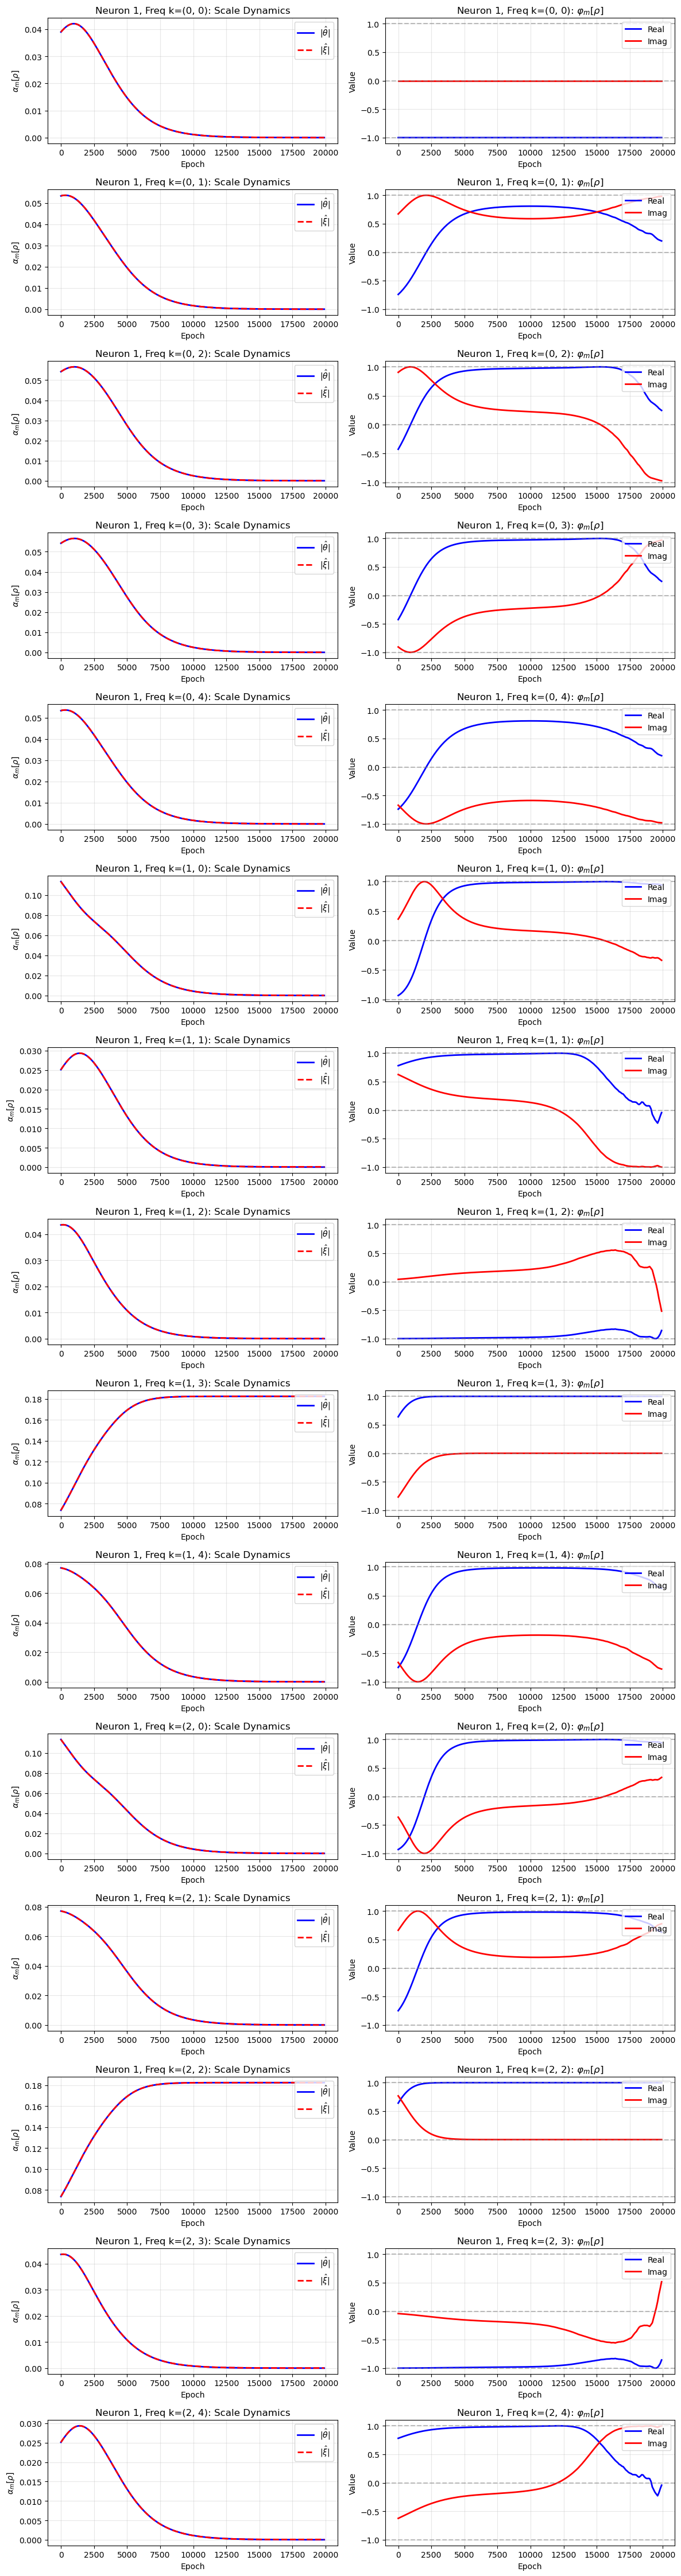

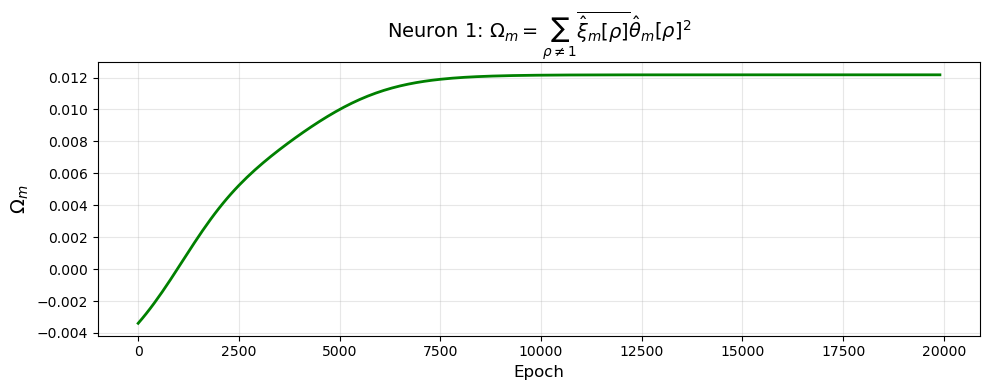

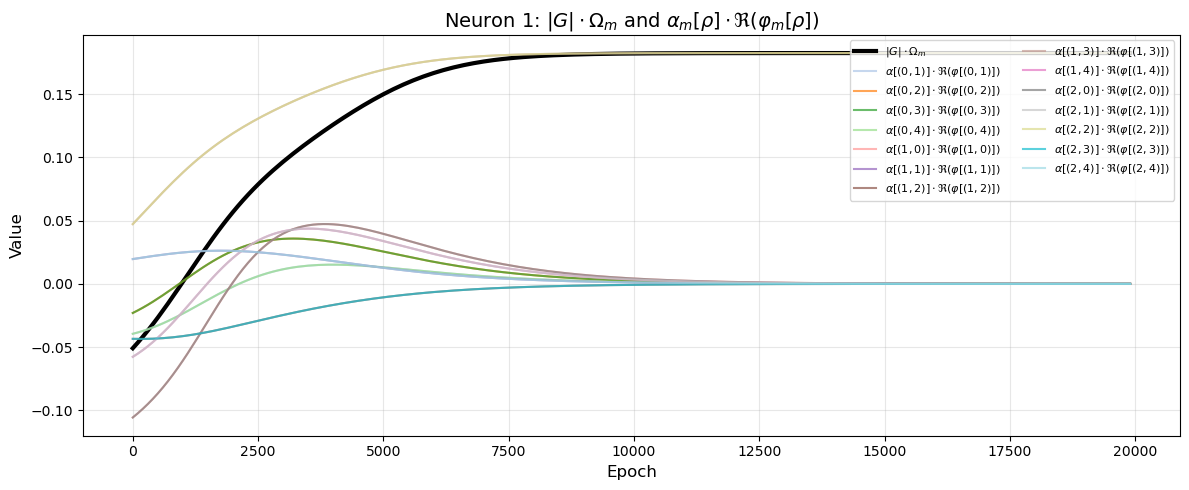

In [75]:
# === Analyze a specific neuron ===
# Change this to analyze different neurons
NEURON_TO_ANALYZE = 1

if len(stage1_history.param_snapshots) > 0:
    dynamics = analyze_neuron_dynamics(
        NEURON_TO_ANALYZE, 
        stage1_history.param_snapshots, 
        basis, 
        config.moduli
    )
    
    # Plot per-frequency dynamics for ALL frequencies
    all_freq_indices = list(range(config.d_vocab))
    plot_neuron_dynamics_per_freq(
        NEURON_TO_ANALYZE, 
        dynamics, 
        basis, 
        freq_indices=all_freq_indices
    )
else:
    print("No snapshots available. Re-run training with snapshot_every > 0.")

In [76]:
# === Print Ω_m for top 10 neurons at final epoch ===
if len(stage1_history.param_snapshots) > 0:
    # Get final snapshot
    final_epoch, W_in_final, W_out_final = stage1_history.param_snapshots[-1]
    
    # Compute Ω_m for all neurons
    M = W_in_final.shape[0]
    omega_values = []
    
    for m in range(M):
        # Normalize to unit vectors
        w_in = W_in_final[m]
        w_in = w_in / np.linalg.norm(w_in)
        w_out = W_out_final[:, m]
        w_out = w_out / np.linalg.norm(w_out)
        
        # Transform using paper's L²(G) convention
        theta_hat = basis.transform_paper(torch.from_numpy(w_in).float().unsqueeze(0))[0]
        xi_hat = basis.transform_paper(torch.from_numpy(w_out).float().unsqueeze(0))[0]
        
        # Compute Ω_m = Σ_{ρ≠1} conj(ξ̂[ρ]) · θ̂[ρ]²
        product = torch.conj(xi_hat) * (theta_hat ** 2)
        omega_m = torch.sum(product[1:]).real.item()
        omega_values.append((m, omega_m))
    
    # Sort by Ω_m (descending)
    omega_values.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Top 10 neurons by Ω_m at epoch {final_epoch}")
    print(f"(Paper's L²(G) DFT convention: θ̂[ρ] = (1/|G|) Σ_g θ(g) ρ(g⁻¹))")
    print("=" * 50)
    print(f"{'Rank':<6} {'Neuron':<10} {'Ω_m':<15}")
    print("-" * 50)
    for rank, (neuron_idx, omega_m) in enumerate(omega_values[:10], 1):
        print(f"{rank:<6} {neuron_idx:<10} {omega_m:<15.6f}")
    print("-" * 50)
    
    # Also print sum of all Ω_m
    total_omega = sum(omega for _, omega in omega_values)
    print(f"\nΣ_m Ω_m = {total_omega:.6f}")
    print(f"Mean Ω_m = {total_omega / M:.6f}")
else:
    print("No snapshots available.")

Top 10 neurons by Ω_m at epoch 19900
(Paper's L²(G) DFT convention: θ̂[ρ] = (1/|G|) Σ_g θ(g) ρ(g⁻¹))
Rank   Neuron     Ω_m            
--------------------------------------------------
1      10         0.012172       
2      39         0.012172       
3      18         0.012172       
4      35         0.012172       
5      46         0.012172       
6      49         0.012172       
7      51         0.012172       
8      81         0.012172       
9      100        0.012172       
10     117        0.012172       
--------------------------------------------------

Σ_m Ω_m = 1.555177
Mean Ω_m = 0.012150


In [77]:
1/np.sqrt(2*15**3)

0.012171612389003692